# Phase 5 — Profit strategy (notebook only)

Offline cut-off search and strategy comparison using **frozen Gate B** scorecards:

| Product | Notebook | Artifacts |
|---------|----------|-----------|
| ins | `03_scorecard_ins.ipynb` | `*_ins_v2` |
| css | `03_scorecard_v2.ipynb` | `*_css_v2` |

**Goal:** pick PD approve/decline cut-offs that maximize bank profit on 1975–87 (offline). Course reference: Strategy 4 = **PLN 731,882**.

## §0 — Load ABT + frozen scorecard artifacts

In [1]:
from __future__ import annotations

import json
import pickle
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from credit_scoring.scorecard.scaling import score_applicants
from credit_scoring.scorecard.woe import encode_woe

RANDOM_SEED = 1234
np.random.seed(RANDOM_SEED)

ROOT = Path("..").resolve()
DATA = ROOT / "data"
MODELS = DATA / "06_models"
REPORTING = DATA / "08_reporting"
REPORTING.mkdir(parents=True, exist_ok=True)

ARTIFACTS = {
    "ins": {
        "package": MODELS / "pd_ins_v2.pkl",
        "points": MODELS / "points_table_ins_v2.parquet",
        "calib": MODELS / "calibration_params_ins_v2.json",
    },
    "css": {
        "package": MODELS / "pd_css_v2.pkl",
        "points": MODELS / "points_table_css_v2.parquet",
        "calib": MODELS / "calibration_params_css_v2.json",
    },
}

ECONOMICS = {
    "ins": {"lgd": 0.45, "apr_annual": 0.01, "provision": 0.0},
    "css": {"lgd": 0.55, "apr_annual": 0.18, "provision": 0.0},
}

WINDOW_START = "197501"
WINDOW_END = "198712"

In [2]:
def load_profit_inputs(
    artifacts: dict = ARTIFACTS,
    abt_path: Path | None = None,
    decisions_path: Path | None = None,
) -> dict:
    """Load ABT, decisions, and frozen Gate B packages / points / calibration."""
    abt_path = abt_path or (DATA / "04_feature" / "abt_app.parquet")
    decisions_path = decisions_path or (DATA / "04_feature" / "decisions.parquet")

    for product, paths in artifacts.items():
        for key, path in paths.items():
            if not Path(path).exists():
                raise FileNotFoundError(f"Missing {product} {key}: {path}")

    abt = pd.read_parquet(abt_path)
    decisions = pd.read_parquet(decisions_path)

    packages, points_tables, calibrations = {}, {}, {}
    for product, paths in artifacts.items():
        with open(paths["package"], "rb") as fh:
            packages[product] = pickle.load(fh)
        points_tables[product] = pd.read_parquet(paths["points"])
        with open(paths["calib"], encoding="utf-8") as fh:
            calibrations[product] = json.load(fh)[product]

    return {
        "abt": abt,
        "decisions": decisions,
        "packages": packages,
        "points_tables": points_tables,
        "calibrations": calibrations,
    }

In [3]:
# --- checkpoint: load_profit_inputs ---
inputs = load_profit_inputs()
abt = inputs["abt"]
decisions = inputs["decisions"]
packages = inputs["packages"]
points_tables = inputs["points_tables"]
calibrations = inputs["calibrations"]

assert "aid" in abt.columns and "product" in abt.columns
for product in ("ins", "css"):
    assert packages[product]["product"] == product
    assert len(packages[product]["features"]) >= 1
    assert "intercept" in calibrations[product] or "a" in calibrations[product]
    assert {"feature", "bin", "points"}.issubset(points_tables[product].columns)

print(
    f"checkpoint load_profit_inputs: abt={abt.shape} decisions={decisions.shape} | "
    f"ins features={len(packages['ins']['features'])} "
    f"css features={len(packages['css']['features'])}"
)
print("ins features:", packages["ins"]["features"])
print("css features:", packages["css"]["features"])
print("calibrations:", {p: calibrations[p] for p in ("ins", "css")})
display(points_tables["ins"].head(3))
display(points_tables["css"].head(3))

checkpoint load_profit_inputs: abt=(49224, 208) decisions=(49224, 8) | ins features=7 css features=8
ins features: ['act_age_WOE', 'act_cins_cc_WOE', 'act_cins_n_statB_WOE', 'app_char_job_code_WOE', 'app_char_marital_status_WOE', 'app_number_of_children_WOE', 'app_spendings_WOE']
css features: ['act_ccss_maxdue_WOE', 'act_ccss_n_loan_WOE', 'act_ccss_min_pninst_WOE', 'act_call_cc_WOE', 'act_ccss_dueutl_WOE', 'app_char_marital_status_WOE', 'app_char_job_code_WOE', 'act_ccss_n_statC_WOE']
calibrations: {'ins': {'intercept': 23.25022106845082, 'coef': -0.04738868244582047, 'target': 'default12', 'score_col': 'score'}, 'css': {'intercept': 17.078947846152293, 'coef': -0.035796280485352994, 'target': 'default12', 'score_col': 'score'}}


,feature,bin,woe,points
0,act_age_WOE,42.0 <= act_age < 62.0,-0.038543,-1.612085
1,act_age_WOE,62.0 <= act_age,0.265540,11.106265
2,act_age_WOE,act_age < 42.0,-0.793255,-33.178009


,feature,bin,woe,points
0,act_ccss_maxdue_WOE,1.5 <= act_ccss_maxdue,-1.460509,-31.219244
1,act_ccss_maxdue_WOE,act_ccss_maxdue < 1.5,1.025151,21.913207
2,act_ccss_n_loan_WOE,"2, 7",1.199775,20.943165


## §1 — Calibration helpers + score to PD

In [4]:
def normalize_calib_params(params: dict) -> tuple[float, float]:
    """Return Platt (a, b) from either a/b or intercept/coef keys."""
    if "a" in params and "b" in params:
        return float(params["a"]), float(params["b"])
    if "intercept" in params and "coef" in params:
        return float(params["intercept"]), float(params["coef"])
    raise KeyError(f"Calibration params need a/b or intercept/coef; got {sorted(params)}")


def score_to_pd(score, a: float, b: float) -> np.ndarray:
    """Calibrated PD = 1 / (1 + exp(-(a + b * score)))."""
    score_arr = np.asarray(score, dtype=float)
    return 1.0 / (1.0 + np.exp(-(a + b * score_arr)))

In [5]:
# --- checkpoint: normalize_calib_params ---
_a_ins, _b_ins = normalize_calib_params(calibrations["ins"])
_a_css, _b_css = normalize_calib_params(calibrations["css"])
assert _b_ins < 0 and _b_css < 0
print(f"checkpoint normalize_calib_params: ins a={_a_ins:.4f} b={_b_ins:.6f}")
print(f"checkpoint normalize_calib_params: css a={_a_css:.4f} b={_b_css:.6f}")
display(pd.DataFrame(
    [
        {"product": "ins", "a": _a_ins, "b": _b_ins},
        {"product": "css", "a": _a_css, "b": _b_css},
    ]
))

checkpoint normalize_calib_params: ins a=23.2502 b=-0.047389
checkpoint normalize_calib_params: css a=17.0789 b=-0.035796


,product,a,b
0,ins,23.250221,-0.047389
1,css,17.078948,-0.035796


In [6]:
# --- checkpoint: score_to_pd ---
_scores = np.array([400.0, 500.0, 600.0])
_pds = score_to_pd(_scores, _a_ins, _b_ins)
assert np.all((_pds > 0) & (_pds < 1))
assert np.all(np.diff(_pds) < 0), "PD should fall as score rises when b<0"
_cp_score_pd = pd.DataFrame({"score": _scores, "pd": _pds})
print("checkpoint score_to_pd (ins calib):")
display(_cp_score_pd)

checkpoint score_to_pd (ins calib):


,score,pd
0,400.0,0.986544
1,500.0,0.390760
2,600.0,0.005580


## §2 — Score ABT with frozen Gate B packages

Uses notebook-style numeric bin labels (`intervals` on the binning map) so points-table bins match.

In [7]:
def _assign_numeric_bin(x, edges, intervals, missing_label, missing_bin):
    """Assign a value to a notebook-style numeric interval label."""
    if pd.isna(x):
        return missing_label if missing_bin else intervals[0]
    for i in range(len(edges) - 1):
        left, right = edges[i], edges[i + 1]
        if left == -np.inf and right == np.inf:
            return intervals[i]
        if left == -np.inf and x < right:
            return intervals[i]
        if right == np.inf and x >= left:
            return intervals[i]
        if left <= x < right:
            return intervals[i]
    return intervals[-1]


def apply_bins_notebook(df: pd.DataFrame, binning_maps: dict) -> pd.DataFrame:
    """Apply ASB binning maps (interval labels) and add ``{feature}_GRP`` columns."""
    base = df.drop(columns=[c for c in df.columns if c.endswith("_GRP")], errors="ignore")
    new_cols = {}
    for feat, spec in binning_maps.items():
        grp_col = f"{feat}_GRP"
        if spec["type"] == "numeric":
            intervals = spec.get("intervals")
            if not intervals:
                raise ValueError(f"{feat}: numeric binning map missing intervals (need Gate B package)")
            new_cols[grp_col] = base[feat].apply(
                lambda x, s=spec: _assign_numeric_bin(
                    x, s["edges"], s["intervals"], s["missing_label"], s.get("missing_bin", False)
                )
            )
        elif spec["type"] == "nominal":
            s = base[feat]
            missing_mask = s.isna()
            mapped = s.astype("string").map(spec["category_map"]).fillna(spec["other_label"])
            mapped.loc[missing_mask] = spec["missing_label"]
            new_cols[grp_col] = mapped.astype("string")
        else:
            raise ValueError(f"Unknown binning type for {feat}: {spec['type']}")
    return pd.concat([base, pd.DataFrame(new_cols, index=base.index)], axis=1).copy()


def woe_tables_to_maps(woe_tables: dict) -> dict[str, pd.DataFrame]:
    """Convert model_package['woe_tables'] (*_WOE keys) to encode_woe maps (*_GRP keys)."""
    out = {}
    for key, table in woe_tables.items():
        feat = key[: -len("_WOE")] if key.endswith("_WOE") else key
        out[f"{feat}_GRP"] = table
    return out


def score_product_slice(
    abt_slice: pd.DataFrame,
    package: dict,
    points_table: pd.DataFrame,
    calib: dict,
) -> pd.DataFrame:
    """Score one product slice: bins -> WOE -> points score -> calibrated PD."""
    if abt_slice.empty:
        return pd.DataFrame(
            columns=[
                "aid", "cid", "product", "period", "app_loan_amount", "app_n_installments",
                "default12", "act_cus_active", "agr12_Max_CMaxA_Due", "score", "pd",
            ]
        )

    product = package["product"]
    binning_maps = package["binning_maps"]
    woe_maps = woe_tables_to_maps(package["woe_tables"])
    a, b = normalize_calib_params(calib)

    binned = apply_bins_notebook(abt_slice, binning_maps)
    encoded = encode_woe(binned, woe_maps)
    missing = [f for f in package["features"] if f not in encoded.columns]
    if missing:
        raise ValueError(f"{product}: missing WOE columns after encode: {missing}")

    scored = score_applicants(encoded, package, points_table)
    keep_cols = [
        c
        for c in [
            "aid", "cid", "product", "period", "app_loan_amount", "app_n_installments",
            "default12", "act_cus_active", "agr12_Max_CMaxA_Due",
        ]
        if c in abt_slice.columns
    ]
    out = abt_slice[keep_cols].copy().reset_index(drop=True)
    out = out.merge(scored[["aid", "score"]], on="aid", how="left")
    out["pd"] = score_to_pd(out["score"].to_numpy(), a, b)
    out["product"] = product
    return out


def score_abt_application(
    abt: pd.DataFrame,
    packages: dict,
    points_tables: dict,
    calibrations: dict,
) -> pd.DataFrame:
    """Score full ABT with per-product Gate B packages; row grain = aid."""
    frames = []
    for product in ("ins", "css"):
        slice_ = abt.loc[abt["product"].eq(product)].copy()
        frames.append(
            score_product_slice(
                slice_,
                packages[product],
                points_tables[product],
                calibrations[product],
            )
        )
    out = pd.concat(frames, ignore_index=True)
    if not out["aid"].is_unique:
        raise ValueError("duplicate aid after scoring")
    return out

In [8]:
# --- checkpoint: score_product_slice ---
_cp_ins = abt.loc[abt["product"].eq("ins")].sample(10, random_state=RANDOM_SEED)
_cp_scored_ins = score_product_slice(
    _cp_ins, packages["ins"], points_tables["ins"], calibrations["ins"]
)
assert len(_cp_scored_ins) == 10
assert {"aid", "score", "pd"}.issubset(_cp_scored_ins.columns)
assert ((_cp_scored_ins["pd"] > 0) & (_cp_scored_ins["pd"] < 1)).all()
assert _cp_scored_ins["score"].nunique() >= 2
print("checkpoint score_product_slice (ins n=10):")
display(_cp_scored_ins[["aid", "score", "pd", "default12", "app_loan_amount"]])

checkpoint score_product_slice (ins n=10):


,aid,score,pd,default12,app_loan_amount
0,ins1979071200031,578.989862,0.014959,1.0,4704.0
1,ins1984031300021,536.465364,0.102278,0.0,7488.0
2,ins1984072100013,565.429944,0.028065,0.0,2364.0
3,ins1980052300021,557.404084,0.040527,0.0,2808.0
4,ins1977052900021,581.275547,0.013444,0.0,5784.0
5,ins1982010300041,595.236092,0.006983,1.0,7968.0
6,ins1982121600011,557.404084,0.040527,0.0,4140.0
7,ins1983102500031,576.583057,0.016736,0.0,3456.0
8,ins1982012500041,595.236092,0.006983,0.0,2940.0
9,ins1985022800021,589.301407,0.009230,0.0,4140.0


In [9]:
# --- checkpoint: score_abt_application (small mixed sample) ---
_cp_mixed = pd.concat(
    [
        abt.loc[abt["product"].eq("ins")].sample(25, random_state=1),
        abt.loc[abt["product"].eq("css")].sample(25, random_state=2),
    ],
    ignore_index=True,
)
_cp_scored_mixed = score_abt_application(
    _cp_mixed, packages, points_tables, calibrations
)
assert len(_cp_scored_mixed) == 50
print("checkpoint score_abt_application (n=50):")
print(_cp_scored_mixed["product"].value_counts().to_dict())
display(_cp_scored_mixed.groupby("product")["pd"].describe()[["count", "mean", "std", "min", "max"]])
display(_cp_scored_mixed.head())

checkpoint score_abt_application (n=50):
{'ins': 25, 'css': 25}


,count,mean,std,min,max
product,,,,,
css,25.0,0.498974,0.314264,0.152122,0.993504
ins,25.0,0.112846,0.193829,0.006983,0.750416


,aid,cid,product,period,app_loan_amount,app_n_installments,default12,act_cus_active,agr12_Max_CMaxA_Due,score,pd
0,ins1979122100021,0000012893,ins,197912,1980.0,12.0,0.0,NaN,NaN,550.003514,0.056587
1,ins1987121000011,0000023196,ins,198712,4272.0,24.0,0.0,NaN,NaN,565.429944,0.028065
2,ins1976022300032,0000000108,ins,197602,876.0,12.0,1.0,1.0,7.0,511.576586,0.270375
3,ins1976122900021,0000009031,ins,197612,8028.0,36.0,1.0,NaN,NaN,492.561051,0.477116
4,ins1982030600021,0000015756,ins,198203,5904.0,24.0,0.0,NaN,NaN,550.743047,0.054745


In [10]:
# Full ABT scoring (after checkpoints)
scored = score_abt_application(abt, packages, points_tables, calibrations)
scored = scored.merge(decisions[["aid", "decision", "decline_reason"]], on="aid", how="left")

print(f"scored ABT: {len(scored):,} rows")
display(scored.head())

_acc = scored.loc[
    scored["decision"].eq("A")
    & scored["period"].between(WINDOW_START, WINDOW_END)
]
_sanity = (
    _acc.groupby("product")
    .agg(n=("aid", "size"), mean_pd=("pd", "mean"), mean_default=("default12", "mean"))
    .reset_index()
)
print("sanity (decision=A, 197501-198712): mean PD vs mean default12")
display(_sanity)

scored ABT: 49,224 rows


,aid,cid,product,period,app_loan_amount,app_n_installments,default12,act_cus_active,agr12_Max_CMaxA_Due,score,pd,decision,decline_reason
0,ins1975010100011,0000006457,ins,197501,7380.0,36.0,0.0,NaN,NaN,590.543602,0.008707,A,999ok
1,ins1975010100021,0000006458,ins,197501,3132.0,12.0,1.0,NaN,NaN,575.856705,0.017312,A,999ok
2,ins1975010100023,0000000064,ins,197501,2916.0,12.0,0.0,1.0,7.0,483.644517,0.581989,A,999ok
3,ins1975010100031,0000006459,ins,197501,2076.0,12.0,0.0,NaN,NaN,563.144259,0.031176,A,999ok
4,ins1975010100033,0000000014,ins,197501,5016.0,24.0,0.0,1.0,7.0,469.683973,0.729585,A,999ok


sanity (decision=A, 197501-198712): mean PD vs mean default12


,product,n,mean_pd,mean_default
0,css,25587,0.635216,0.683755
1,ins,23637,0.116914,0.137648


## §3 — Loan P&L accounting (course formula)

In [11]:
def installment_amount(loan: float, n: int, apr_monthly: float) -> float:
    """Annuity installment: loan * apr * (1+apr)^n / ((1+apr)^n - 1)."""
    loan = float(loan)
    n = int(n)
    apr_monthly = float(apr_monthly)
    if n <= 0:
        raise ValueError("n_installments must be positive")
    if apr_monthly == 0:
        return loan / n
    factor = (1.0 + apr_monthly) ** n
    return loan * apr_monthly * factor / (factor - 1.0)


def loan_pnl(
    loan: float,
    n_installments: int,
    product: str,
    default12,
    economics: dict = ECONOMICS,
) -> dict:
    """Per-loan Income / EL / Profit matching SAS calibration.sas / all_contents.sas."""
    if product not in economics:
        raise KeyError(f"Unknown product {product}")
    eco = economics[product]
    lgd = float(eco["lgd"])
    apr_monthly = float(eco["apr_annual"]) / 12.0
    provision = float(eco.get("provision", 0.0))

    if pd.isna(default12) or default12 in (".i", ".d"):
        default12 = 0
    default12 = int(default12)

    inst = installment_amount(loan, n_installments, apr_monthly)
    el = float(loan) * lgd if default12 == 1 else 0.0
    income = 0.0
    if default12 == 0:
        income = n_installments * inst + float(loan) * (provision - 1.0)
    profit = income - el
    return {
        "income": income,
        "el": el,
        "profit": profit,
        "installment": inst,
        "lgd": lgd,
        "apr_monthly": apr_monthly,
    }


def compute_pnl_table(scored: pd.DataFrame, economics: dict = ECONOMICS) -> pd.DataFrame:
    """Add income / el / profit / installment columns to a scored frame."""
    out = scored.copy()
    rows = [
        loan_pnl(
            loan=r.app_loan_amount,
            n_installments=int(r.app_n_installments),
            product=r.product,
            default12=r.default12,
            economics=economics,
        )
        for r in out.itertuples(index=False)
    ]
    pnl = pd.DataFrame(rows)
    for col in ("income", "el", "profit", "installment"):
        out[col] = pnl[col].to_numpy()
    return out


def filter_profit_window(
    df: pd.DataFrame,
    start: str = WINDOW_START,
    end: str = WINDOW_END,
) -> pd.DataFrame:
    """Keep rows with period in [start, end] inclusive (YYYYMM strings)."""
    return df.loc[df["period"].astype(str).between(start, end)].copy()

In [12]:
# --- checkpoint: installment_amount ---
_inst = installment_amount(5000, 12, 0.18 / 12)
assert _inst > 5000 / 12
print(f"checkpoint installment_amount: loan=5000 n=12 apr_m=0.18/12 -> {_inst:.4f}")

checkpoint installment_amount: loan=5000 n=12 apr_m=0.18/12 -> 458.4000


In [13]:
# --- checkpoint: loan_pnl ---
_good = loan_pnl(5000, 12, "css", default12=0, economics=ECONOMICS)
_bad = loan_pnl(5000, 12, "css", default12=1, economics=ECONOMICS)
assert _good["el"] == 0 and _good["profit"] == _good["income"] > 0
assert _bad["income"] == 0 and abs(_bad["el"] - 5000 * 0.55) < 1e-9
assert abs(_bad["profit"] + _bad["el"]) < 1e-9
_cp_pnl = pd.DataFrame(
    [
        {"case": "good_css", **_good},
        {"case": "bad_css", **_bad},
    ]
)
print("checkpoint loan_pnl:")
display(_cp_pnl)

checkpoint loan_pnl:


,case,income,el,profit,installment,lgd,apr_monthly
0,good_css,500.799574,0.0,500.799574,458.399965,0.55,0.015
1,bad_css,0.000000,2750.0,-2750.000000,458.399965,0.55,0.015


In [14]:
# --- checkpoint: compute_pnl_table ---
_cp_pnl_tbl = compute_pnl_table(_cp_scored_ins, ECONOMICS)
assert {"income", "el", "profit", "installment"}.issubset(_cp_pnl_tbl.columns)
assert np.allclose(_cp_pnl_tbl["profit"], _cp_pnl_tbl["income"] - _cp_pnl_tbl["el"])
print("checkpoint compute_pnl_table (ins n=10):")
display(
    _cp_pnl_tbl[
        ["aid", "default12", "app_loan_amount", "app_n_installments", "income", "el", "profit"]
    ]
)

checkpoint compute_pnl_table (ins n=10):


,aid,default12,app_loan_amount,app_n_installments,income,el,profit
0,ins1979071200031,1.0,4704.0,12.0,0.000000,2116.8,-2116.800000
1,ins1984031300021,0.0,7488.0,24.0,78.249061,0.0,78.249061
2,ins1984072100013,0.0,2364.0,12.0,12.824555,0.0,12.824555
3,ins1980052300021,0.0,2808.0,12.0,15.233228,0.0,15.233228
4,ins1977052900021,0.0,5784.0,24.0,60.442384,0.0,60.442384
5,ins1982010300041,1.0,7968.0,24.0,0.000000,3585.6,-3585.600000
6,ins1982121600011,0.0,4140.0,36.0,64.135127,0.0,64.135127
7,ins1983102500031,0.0,3456.0,36.0,53.538888,0.0,53.538888
8,ins1982012500041,0.0,2940.0,12.0,15.949320,0.0,15.949320
9,ins1985022800021,0.0,4140.0,36.0,64.135127,0.0,64.135127


In [15]:
# Full P&L on scored ABT + window filter
scored_pnl = compute_pnl_table(scored, ECONOMICS)
scored_window = filter_profit_window(scored_pnl, WINDOW_START, WINDOW_END)

# --- checkpoint: filter_profit_window ---
assert scored_window["period"].min() >= WINDOW_START
assert scored_window["period"].max() <= WINDOW_END
print(
    f"checkpoint filter_profit_window: {len(scored_pnl):,} -> {len(scored_window):,} | "
    f"period [{scored_window['period'].min()}, {scored_window['period'].max()}]"
)
display(
    scored_window.groupby("product")
    .agg(n=("aid", "size"), total_profit=("profit", "sum"), bad_rate=("default12", "mean"))
    .reset_index()
)

checkpoint filter_profit_window: 49,224 -> 49,224 | period [197501, 198712]


,product,n,total_profit,bad_rate
0,css,25587,-3.162731e+07,0.683755
1,ins,23637,-7.824395e+06,0.137648


## §4 — Profit U-curves and optimal PD cut-offs

**Curve construction (as-if):** sort product rows in the window by ascending PD; cumulative accept-all-below-threshold.
Peaks of `profit_cum` become candidate cut-offs for `STRATEGY` (do not hard-code SGH 27.24% / 8.19%).

In [16]:
def profit_curve_by_pd(
    df: pd.DataFrame,
    product: str,
    pd_col: str = "pd",
) -> pd.DataFrame:
    """Cumulative profit / AR vs PD threshold for one product (sorted ascending PD)."""
    sub = df.loc[df["product"].eq(product)].copy()
    if sub.empty:
        return pd.DataFrame(
            columns=["pd", "n", "n_cum", "ar", "profit", "profit_cum", "bad_rate_cum", "defaults_cum"]
        )
    sub = sub.sort_values(pd_col, ascending=True).reset_index(drop=True)
    g = (
        sub.groupby(pd_col, sort=True)
        .agg(n=("aid", "size"), profit=("profit", "sum"), defaults=("default12", "sum"))
        .reset_index()
        .rename(columns={pd_col: "pd"})
    )
    g["n_cum"] = g["n"].cumsum()
    g["profit_cum"] = g["profit"].cumsum()
    g["defaults_cum"] = g["defaults"].cumsum()
    g["ar"] = g["n_cum"] / g["n"].sum()
    g["bad_rate_cum"] = g["defaults_cum"] / g["n_cum"]
    return g[
        ["pd", "n", "n_cum", "ar", "profit", "profit_cum", "bad_rate_cum", "defaults_cum"]
    ]


def find_optimal_cutoff(curve: pd.DataFrame) -> dict:
    """Return cut-off at max profit_cum; ties -> lower PD (more conservative)."""
    if curve.empty:
        raise ValueError("empty profit curve")
    peak = curve["profit_cum"].max()
    at_peak = curve.loc[curve["profit_cum"] == peak]
    row = at_peak.nsmallest(1, "pd").iloc[0]
    return {
        "pd_cutoff": float(row["pd"]),
        "peak_profit": float(row["profit_cum"]),
        "ar_at_peak": float(row["ar"]),
        "n_accepted": int(row["n_cum"]),
        "accepted_bad_rate": float(row["bad_rate_cum"]),
    }

In [17]:
# U-curves on window (as-if): all apps with non-null PD
curve_pool = scored_window.dropna(subset=["pd"]).copy()

# --- checkpoint: profit_curve_by_pd ---
curve_css = profit_curve_by_pd(curve_pool, "css")
assert curve_css["ar"].is_monotonic_increasing
assert np.isfinite(curve_css["profit_cum"]).all()
print("checkpoint profit_curve_by_pd (css): head + top profit_cum")
display(curve_css.head())
display(curve_css.nlargest(3, "profit_cum"))

checkpoint profit_curve_by_pd (css): head + top profit_cum


,pd,n,n_cum,ar,profit,profit_cum,bad_rate_cum,defaults_cum
0,0.092469,1,1,0.000039,-2750.000000,-2750.000000,1.000000,1.0
1,0.100466,117,118,0.004612,63561.900343,60811.900343,0.127119,15.0
2,0.107932,4,122,0.004768,3963.568945,64775.469288,0.122951,15.0
3,0.117109,8,130,0.005081,4186.245654,68961.714943,0.123077,16.0
4,0.125639,12,142,0.005550,8149.814600,77111.529543,0.119718,17.0


,pd,n,n_cum,ar,profit,profit_cum,bad_rate_cum,defaults_cum
28,0.208233,10,2791,0.109079,2427.137891,1.359005e+06,0.134719,376.0
23,0.196383,1,2752,0.107555,990.892236,1.357769e+06,0.132994,366.0
22,0.194198,19,2751,0.107516,15086.060254,1.356778e+06,0.133043,366.0


In [18]:
curve_ins = profit_curve_by_pd(curve_pool, "ins")

# --- checkpoint: find_optimal_cutoff ---
opt_css = find_optimal_cutoff(curve_css)
opt_ins = find_optimal_cutoff(curve_ins)
assert 0 < opt_css["pd_cutoff"] < 1
assert 0 < opt_ins["pd_cutoff"] < 1
assert np.isfinite(opt_css["peak_profit"]) and np.isfinite(opt_ins["peak_profit"])
print("checkpoint find_optimal_cutoff css:", opt_css)
print("checkpoint find_optimal_cutoff ins:", opt_ins)
display(pd.DataFrame([{"product": "css", **opt_css}, {"product": "ins", **opt_ins}]))

checkpoint find_optimal_cutoff css: {'pd_cutoff': 0.20823287081530759, 'peak_profit': 1359004.750763704, 'ar_at_peak': 0.10907882909289873, 'n_accepted': 2791, 'accepted_bad_rate': 0.13471873880329632}
checkpoint find_optimal_cutoff ins: {'pd_cutoff': 0.0053289790410611425, 'peak_profit': 9271.778446801805, 'ar_at_peak': 0.02309937809366671, 'n_accepted': 546, 'accepted_bad_rate': 0.007326007326007326}


,product,pd_cutoff,peak_profit,ar_at_peak,n_accepted,accepted_bad_rate
0,css,0.208233,1.359005e+06,0.109079,2791,0.134719
1,ins,0.005329,9.271778e+03,0.023099,546,0.007326


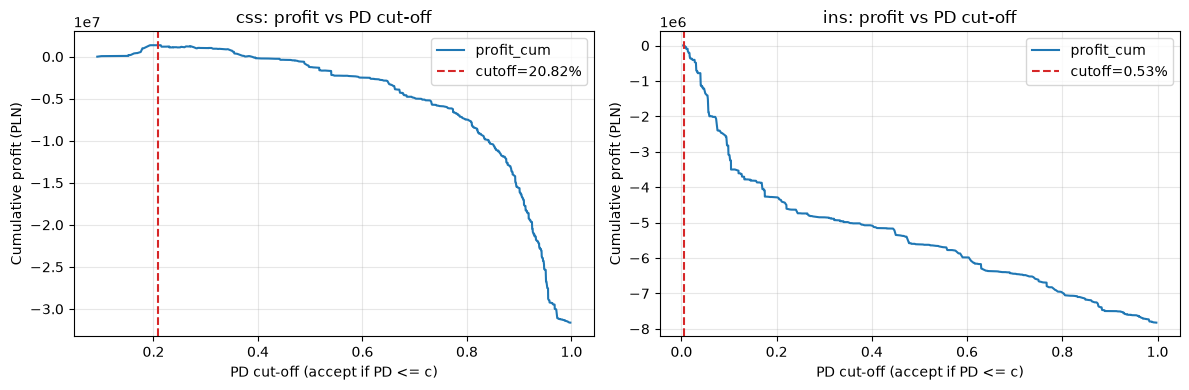

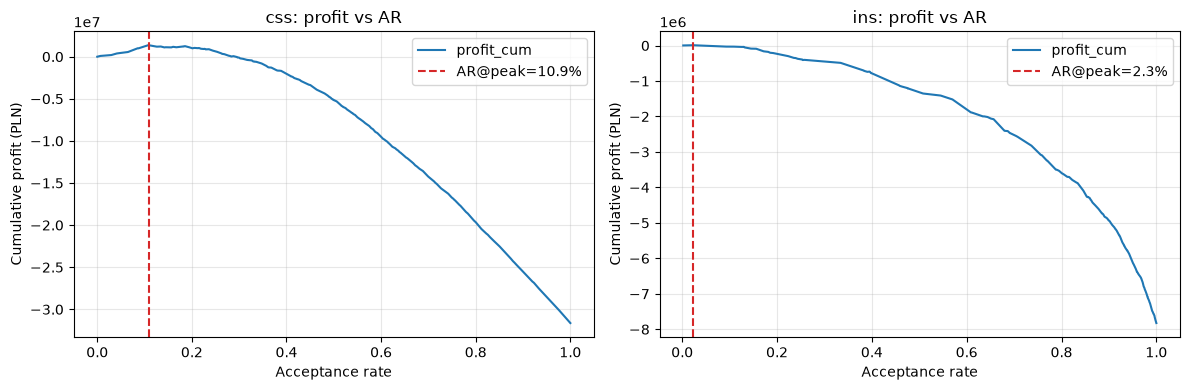

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, product, curve, opt in [
    (axes[0], "css", curve_css, opt_css),
    (axes[1], "ins", curve_ins, opt_ins),
]:
    ax.plot(curve["pd"], curve["profit_cum"], label="profit_cum")
    ax.axvline(opt["pd_cutoff"], color="C3", ls="--", label=f"cutoff={opt['pd_cutoff']:.2%}")
    ax.set_title(f"{product}: profit vs PD cut-off")
    ax.set_xlabel("PD cut-off (accept if PD <= c)")
    ax.set_ylabel("Cumulative profit (PLN)")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, product, curve, opt in [
    (axes[0], "css", curve_css, opt_css),
    (axes[1], "ins", curve_ins, opt_ins),
]:
    ax.plot(curve["ar"], curve["profit_cum"], label="profit_cum")
    ax.axvline(opt["ar_at_peak"], color="C3", ls="--", label=f"AR@peak={opt['ar_at_peak']:.1%}")
    ax.set_title(f"{product}: profit vs AR")
    ax.set_xlabel("Acceptance rate")
    ax.set_ylabel("Cumulative profit (PLN)")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## §5 — Strategy rules, evaluate, compare

In [20]:
STRATEGY = {
    "window_start": WINDOW_START,
    "window_end": WINDOW_END,
    "burn_in_before": "197501",
    "economics": ECONOMICS,
    "cutoffs": {
        "pd_css": opt_css["pd_cutoff"],
        "pd_ins_high": opt_ins["pd_cutoff"],
    },
    "bad_customer": {
        "enabled": True,
        "feature": "agr12_Max_CMaxA_Due",
        "threshold": 3,
    },
}

print("STRATEGY cutoffs from U-curves:")
display(pd.DataFrame([STRATEGY["cutoffs"]]))


def apply_strategy(scored: pd.DataFrame, rules: dict) -> pd.DataFrame:
    """Apply decision rules; first matching decline wins.

    Priority: burn-in keep A -> 998 inactive css -> bad customer -> PD css -> PD ins.
    """
    out_cols = [
        "cid", "aid", "product", "period",
        "decision", "decline_reason",
        "app_loan_amount", "app_n_installments", "pd",
    ]
    df = scored.copy()
    decision = pd.Series("A", index=df.index, dtype="string")
    reason = pd.Series("999ok", index=df.index, dtype="string")

    burn_in_before = rules.get("burn_in_before", "197501")
    period = df["period"].astype(str)
    burn = period < burn_in_before

    inactive_css = df["product"].eq("css") & (df["act_cus_active"] != 1) & (~burn)
    decision.loc[inactive_css] = "N"
    reason.loc[inactive_css] = "998 not active customer"

    bad_cfg = rules.get("bad_customer") or {}
    if bad_cfg.get("enabled", False):
        feat = bad_cfg["feature"]
        thr = bad_cfg["threshold"]
        if feat not in df.columns:
            raise KeyError(f"bad_customer feature missing: {feat}")
        bad = (~burn) & decision.eq("A") & df[feat].notna() & (df[feat] > thr)
        decision.loc[bad] = "D"
        reason.loc[bad] = "1 bad customer"

    cut = rules.get("cutoffs") or {}
    pd_css = cut.get("pd_css")
    pd_ins = cut.get("pd_ins_high")

    if pd_css is not None:
        css_cut = (
            (~burn) & decision.eq("A") & df["product"].eq("css") & (df["pd"] > pd_css)
        )
        decision.loc[css_cut] = "D"
        reason.loc[css_cut] = "1 PD cut-off on css"

    if pd_ins is not None:
        ins_cut = (
            (~burn) & decision.eq("A") & df["product"].eq("ins") & (df["pd"] > pd_ins)
        )
        decision.loc[ins_cut] = "D"
        reason.loc[ins_cut] = "2 PD cut-off on ins"

    decision.loc[burn] = "A"
    reason.loc[burn] = "999ok"

    slim = df[
        [c for c in ["cid", "aid", "product", "period", "app_loan_amount", "app_n_installments", "pd"] if c in df.columns]
    ].copy()
    slim["decision"] = decision.to_numpy()
    slim["decline_reason"] = reason.to_numpy()
    return slim[out_cols]


def evaluate_strategy(
    scored_pnl: pd.DataFrame,
    decisions: pd.DataFrame,
    window_start: str = WINDOW_START,
    window_end: str = WINDOW_END,
) -> dict:
    """Profit metrics on decision=='A' inside window; AR on decisionable apps (excl N)."""
    base = scored_pnl.copy()
    if "decision" in base.columns:
        base = base.drop(columns=["decision", "decline_reason"], errors="ignore")
    m = base.merge(
        decisions[["aid", "decision", "decline_reason"]],
        on="aid",
        how="inner",
    )
    m = filter_profit_window(m, window_start, window_end)

    accepted = m.loc[m["decision"].eq("A")]
    decisionable = m.loc[m["decision"].isin(["A", "D"])]

    def _ar(product: str) -> float:
        d = decisionable.loc[decisionable["product"].eq(product)]
        if len(d) == 0:
            return float("nan")
        return float(d["decision"].eq("A").mean())

    def _bad(product: str) -> float:
        a = accepted.loc[accepted["product"].eq(product)]
        if len(a) == 0:
            return float("nan")
        return float(a["default12"].mean())

    by_product = (
        accepted.groupby("product")
        .agg(
            n_accept=("aid", "size"),
            total_profit=("profit", "sum"),
            total_income=("income", "sum"),
            total_el=("el", "sum"),
            bad_rate=("default12", "mean"),
        )
        .reset_index()
    )
    by_year = accepted.copy()
    by_year["year"] = by_year["period"].astype(str).str[:4]
    by_year = (
        by_year.groupby(["year", "product"], as_index=False)
        .agg(n=("aid", "size"), profit=("profit", "sum"))
    )

    return {
        "total_profit": float(accepted["profit"].sum()),
        "total_income": float(accepted["income"].sum()),
        "total_el": float(accepted["el"].sum()),
        "ar_ins": _ar("ins"),
        "ar_css": _ar("css"),
        "bad_rate_ins": _bad("ins"),
        "bad_rate_css": _bad("css"),
        "n_apps": int(len(m)),
        "n_accept": int(len(accepted)),
        "n_N": int(m["decision"].eq("N").sum()),
        "by_product": by_product,
        "by_year": by_year,
    }


def compare_strategies(results: list[dict]) -> pd.DataFrame:
    """Build strategy comparison table; append SGH St4 reference row."""
    rows = []
    for r in results:
        rows.append(
            {
                "strategy": r["name"],
                "css_ar": r["eval"]["ar_css"],
                "ins_ar": r["eval"]["ar_ins"],
                "total_profit": r["eval"]["total_profit"],
                "n_accept": r["eval"]["n_accept"],
                "source": r.get("source", "offline"),
            }
        )
    rows.append(
        {
            "strategy": "SGH St4 reference",
            "css_ar": 0.0868,
            "ins_ar": 0.2600,
            "total_profit": 731_882.0,
            "n_accept": np.nan,
            "source": "course",
        }
    )
    return pd.DataFrame(rows)

STRATEGY cutoffs from U-curves:


,pd_css,pd_ins_high
0,0.208233,0.005329


In [21]:
# --- checkpoint: apply_strategy (fixtures) ---
_fixtures = pd.DataFrame(
    [
        {
            "cid": "c1", "aid": "a1", "product": "css", "period": "198001",
            "app_loan_amount": 1000, "app_n_installments": 12,
            "pd": 0.05, "act_cus_active": 0, "agr12_Max_CMaxA_Due": 0,
            "default12": 0, "income": 0, "el": 0, "profit": 0,
        },
        {
            "cid": "c2", "aid": "a2", "product": "ins", "period": "198001",
            "app_loan_amount": 1000, "app_n_installments": 12,
            "pd": 0.01, "act_cus_active": 1, "agr12_Max_CMaxA_Due": 5,
            "default12": 0, "income": 0, "el": 0, "profit": 0,
        },
        {
            "cid": "c3", "aid": "a3", "product": "css", "period": "198001",
            "app_loan_amount": 1000, "app_n_installments": 12,
            "pd": 0.99, "act_cus_active": 1, "agr12_Max_CMaxA_Due": 0,
            "default12": 0, "income": 0, "el": 0, "profit": 0,
        },
        {
            "cid": "c4", "aid": "a4", "product": "ins", "period": "198001",
            "app_loan_amount": 1000, "app_n_installments": 12,
            "pd": 0.001, "act_cus_active": 1, "agr12_Max_CMaxA_Due": 0,
            "default12": 0, "income": 10, "el": 0, "profit": 10,
        },
        {
            "cid": "c5", "aid": "a5", "product": "css", "period": "197401",
            "app_loan_amount": 1000, "app_n_installments": 12,
            "pd": 0.99, "act_cus_active": 0, "agr12_Max_CMaxA_Due": 9,
            "default12": 0, "income": 0, "el": 0, "profit": 0,
        },
    ]
)
_rules_cp = deepcopy(STRATEGY)
_rules_cp["cutoffs"] = {"pd_css": 0.30, "pd_ins_high": 0.10}
_dec_fix = apply_strategy(_fixtures, _rules_cp)
_expected = {
    "a1": ("N", "998 not active customer"),
    "a2": ("D", "1 bad customer"),
    "a3": ("D", "1 PD cut-off on css"),
    "a4": ("A", "999ok"),
    "a5": ("A", "999ok"),
}
for aid, (d, r) in _expected.items():
    row = _dec_fix.loc[_dec_fix["aid"].eq(aid)].iloc[0]
    assert row["decision"] == d and row["decline_reason"] == r, (aid, row.to_dict())
print("checkpoint apply_strategy (fixtures):")
display(_dec_fix)

_sample = scored_window.sample(min(200, len(scored_window)), random_state=RANDOM_SEED)
_dec_sample = apply_strategy(_sample, STRATEGY)
print("checkpoint apply_strategy (200-row sample) decline_reason counts:")
display(_dec_sample["decline_reason"].value_counts())

checkpoint apply_strategy (fixtures):


,cid,aid,product,period,decision,decline_reason,app_loan_amount,app_n_installments,pd
0,c1,a1,css,198001,N,998 not active customer,1000,12,0.050
1,c2,a2,ins,198001,D,1 bad customer,1000,12,0.010
2,c3,a3,css,198001,D,1 PD cut-off on css,1000,12,0.990
3,c4,a4,ins,198001,A,999ok,1000,12,0.001
4,c5,a5,css,197401,A,999ok,1000,12,0.990


checkpoint apply_strategy (200-row sample) decline_reason counts:


decline_reason
2 PD cut-off on ins    92
1 bad customer         59
1 PD cut-off on css    35
999ok                  14
Name: count, dtype: int64

In [22]:
def _run_named_strategy(name: str, rules: dict, frame: pd.DataFrame) -> dict:
    dec = apply_strategy(frame, rules)
    ev = evaluate_strategy(frame, dec, rules["window_start"], rules["window_end"])
    return {"name": name, "rules": rules, "decisions": dec, "eval": ev, "source": "offline"}


_st0 = deepcopy(STRATEGY)
_st0["bad_customer"]["enabled"] = False
_st0["cutoffs"] = {"pd_css": None, "pd_ins_high": None}

_st_bad = deepcopy(STRATEGY)
_st_bad["cutoffs"] = {"pd_css": None, "pd_ins_high": None}

_st_pd = deepcopy(STRATEGY)
_st_pd["bad_customer"]["enabled"] = False

_st_yours = deepcopy(STRATEGY)

strategy_runs = [
    _run_named_strategy("St0 approve-active (998 only)", _st0, scored_window),
    _run_named_strategy("St_bad_only", _st_bad, scored_window),
    _run_named_strategy("St_pd_both", _st_pd, scored_window),
    _run_named_strategy("St_yours (bad + PD)", _st_yours, scored_window),
]

# --- checkpoint: evaluate_strategy ---
_ev0 = strategy_runs[0]["eval"]
assert "total_profit" in _ev0
print("checkpoint evaluate_strategy (St0):")
display(pd.Series({k: v for k, v in _ev0.items() if k not in ("by_product", "by_year")}))
display(_ev0["by_product"])

checkpoint evaluate_strategy (St0):


total_profit   -3.945171e+07
total_income    1.123043e+07
total_el        5.068214e+07
ar_ins          1.000000e+00
ar_css          1.000000e+00
bad_rate_ins    1.376484e-01
bad_rate_css    6.837545e-01
n_apps          4.922400e+04
n_accept        4.922400e+04
n_N             0.000000e+00
dtype: float64

,product,n_accept,total_profit,total_income,total_el,bad_rate
0,css,25587,-3.162731e+07,1.026069e+07,41888000.0,0.683755
1,ins,23637,-7.824395e+06,9.697429e+05,8794137.6,0.137648


In [23]:
# --- checkpoint: compare_strategies ---
comparison = compare_strategies(strategy_runs)
assert (comparison["strategy"] == "SGH St4 reference").any()
assert comparison.loc[comparison["strategy"].eq("SGH St4 reference"), "total_profit"].iloc[0] == 731_882
print("checkpoint compare_strategies:")
display(
    comparison.style.format(
        {
            "css_ar": "{:.2%}",
            "ins_ar": "{:.2%}",
            "total_profit": "{:,.0f}",
            "n_accept": "{:,.0f}",
        },
        na_rep="—",
    )
)

checkpoint compare_strategies:


,strategy,css_ar,ins_ar,total_profit,n_accept,source
0,St0 approve-active (998 only),100.00%,100.00%,"-39,451,706","49,224",offline
1,St_bad_only,46.89%,95.93%,"-14,395,231","34,671",offline
2,St_pd_both,10.91%,2.31%,"1,368,277","3,337",offline
3,St_yours (bad + PD),9.69%,2.11%,"1,506,547","2,978",offline
4,SGH St4 reference,8.68%,26.00%,"731,882",—,course


## §6 — Conclusion + exports

In [24]:
best = max(strategy_runs, key=lambda r: r["eval"]["total_profit"])
print("Best offline strategy:", best["name"])
print(f"Offline total profit: {best['eval']['total_profit']:,.0f} PLN")
print(f"SGH St4 reference:    731,882 PLN")
print(f"Delta vs reference:   {best['eval']['total_profit'] - 731_882:,.0f} PLN")
print("Chosen cut-offs:", best["rules"]["cutoffs"])
print(
    "Note: offline profit is directional (fixed historical ABT / prior strategy). "
    "Official beat of 731,882 needs closed-loop re-simulation (later)."
)

decisions_strategy = best["decisions"]
profit_by_loan = scored_window.merge(
    decisions_strategy[["aid", "decision", "decline_reason"]].rename(
        columns={"decision": "strategy_decision", "decline_reason": "strategy_decline_reason"}
    ),
    on="aid",
    how="left",
)

profit_summary = comparison.copy()
profit_summary["best_strategy"] = best["name"]
profit_summary["pd_css_cutoff"] = best["rules"]["cutoffs"].get("pd_css")
profit_summary["pd_ins_cutoff"] = best["rules"]["cutoffs"].get("pd_ins_high")

out_dec = REPORTING / "decisions_strategy.parquet"
out_pnl = REPORTING / "profit_by_loan.parquet"
out_sum = REPORTING / "profit_summary.parquet"
decisions_strategy.to_parquet(out_dec, index=False)
profit_by_loan.to_parquet(out_pnl, index=False)
profit_summary.to_parquet(out_sum, index=False)

cutoff_note = {
    "best_strategy": best["name"],
    "cutoffs": best["rules"]["cutoffs"],
    "offline_total_profit": best["eval"]["total_profit"],
    "sgh_st4_reference": 731_882,
    "window": [WINDOW_START, WINDOW_END],
    "artifacts": {"ins": "pd_ins_v2.pkl", "css": "pd_css_v2.pkl"},
}
with open(REPORTING / "profit_strategy_conclusion.json", "w", encoding="utf-8") as fh:
    json.dump(cutoff_note, fh, indent=2)

print("Wrote:")
print(" ", out_dec)
print(" ", out_pnl)
print(" ", out_sum)
print(" ", REPORTING / "profit_strategy_conclusion.json")
display(pd.Series({k: str(v) for k, v in cutoff_note.items()}))

Best offline strategy: St_yours (bad + PD)
Offline total profit: 1,506,547 PLN
SGH St4 reference:    731,882 PLN
Delta vs reference:   774,665 PLN
Chosen cut-offs: {'pd_css': 0.20823287081530759, 'pd_ins_high': 0.0053289790410611425}
Note: offline profit is directional (fixed historical ABT / prior strategy). Official beat of 731,882 needs closed-loop re-simulation (later).
Wrote:
  /Users/mac/Learningnewthings/credit-scoring/data/08_reporting/decisions_strategy.parquet
  /Users/mac/Learningnewthings/credit-scoring/data/08_reporting/profit_by_loan.parquet
  /Users/mac/Learningnewthings/credit-scoring/data/08_reporting/profit_summary.parquet
  /Users/mac/Learningnewthings/credit-scoring/data/08_reporting/profit_strategy_conclusion.json


best_strategy                                         St_yours (bad + PD)
cutoffs                 {'pd_css': 0.20823287081530759, 'pd_ins_high':...
offline_total_profit                                    1506547.208575406
sgh_st4_reference                                                  731882
window                                               ['197501', '198712']
artifacts                {'ins': 'pd_ins_v2.pkl', 'css': 'pd_css_v2.pkl'}
dtype: str